# Foodhub data analysis and recommendations

## Project Python Foundations:
FoodHub Data Analysis

**Context**

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

**Objective**

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

**Data Description**

The data contains the different data related to a food order. The detailed data dictionary is given below.

**Data Dictionary**

order_id: Unique ID of the order
customer_id: ID of the customer who ordered the food
restaurant_name: Name of the restaurant
cuisine_type: Cuisine ordered by the customer
cost_of_the_order: Cost of the order
day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
rating: Rating given by the customer out of 5
food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information


### **Importing the necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### **Loading the dataset**

In [ ]:
path = '/content/drive/MyDrive/Python Course/foodhub_order.csv'
foodhub = pd.read_csv (path)

### **Understanding the data**

**Checking the first 5 rows of the dataset**

In [ ]:
# Return first 5 rows
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


Observation:
The data loaded correctly

**Checking the shape of the dataset**

In [ ]:
# Amount of rows and columns in the dataset
foodhub.shape

(1898, 9)

Observation:
There are 1898 rows and 9 columns in the dataset.

**Checking the data types of the columns in the dataset**

In [ ]:
# Datatypes of the different columns in the dataset
foodhub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Observation:
The following datatypes are present:

1.   **integer** for order id, customer id, food preparation_time, and delivery time,

2.  **object** which contains a string: restaurant name, cuisine type, day of the week, rating. Rating will be more usefull when it is a float type.

3.  **float64** for cost of the order.

dtypes: float64(1 column) , int64(4 columns) , object(4 columns)











### **Find missing values and treat it**



In [ ]:
# Rating is recorded as an object, because "not given" is entered as a string
foodhub['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
foodhub['rating'].apply(type).value_counts()

,count
rating,
<class 'str'>,1898


In [ ]:
# Change rating to a float
foodhub['rating']=foodhub['rating'].replace('Not given', np.nan)
foodhub
foodhub['rating']=foodhub['rating'].astype(float)
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24


Observation:
"Not given" has changed to NaN. Confirmed that NaN values are in dataset.

In [ ]:
#Review rating data type
foodhub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


Observation:
Datatype of rating is datatype: float.

### **Getting statistical summary of numerical data**

In [ ]:
# Statistical summary of the numerical data
# Drop customer id and order id columns, they contain numbers, but are not numerical values
foodhub.drop(['customer_id', 'order_id'], axis=1).describe()


,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1898.000000,1162.000000,1898.000000,1898.000000
mean,16.498851,4.344234,27.371970,24.161749
std,7.483812,0.741478,4.632481,4.972637
min,4.470000,3.000000,20.000000,15.000000
25%,12.080000,4.000000,23.000000,20.000000
50%,14.140000,5.000000,27.000000,25.000000
75%,22.297500,5.000000,31.000000,28.000000
max,35.410000,5.000000,35.000000,33.000000


Observation:
The average preparation time is 27.37 minutes. The minimum preparation time is 20 minutes and the maximum preparation time is 35 minutes.

The delivery time ranges from 24 to 33 minutes, with an average of 24 minutes.

Rating has a count of 1162, which indicates missing values in this column.

### **Obtaining orders that are not rated**


In [ ]:
df=pd.DataFrame(foodhub)
#Sum Nan values
nan_counts=df.isnull().sum()
print(nan_counts)

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64


In [ ]:
# Percentage of NaN counts indicate rating missing data percentage
Percentage = nan_counts/1898 *100
rounded_percentage=round(Percentage,2)
print(rounded_percentage)
print('The percentage missing data is:',rounded_percentage,'%')

order_id                  0.00
customer_id               0.00
restaurant_name           0.00
cuisine_type              0.00
cost_of_the_order         0.00
day_of_the_week           0.00
rating                   38.78
food_preparation_time     0.00
delivery_time             0.00
dtype: float64
The percentage missing data is: order_id                  0.00
customer_id               0.00
restaurant_name           0.00
cuisine_type              0.00
cost_of_the_order         0.00
day_of_the_week           0.00
rating                   38.78
food_preparation_time     0.00
delivery_time             0.00
dtype: float64 %


Observation:
Total number of ratings 'not given' (now NaN) are 736. 38.78% of the ratings are 'not given'. 38.78% of the orders are not rated which presents missing data.

**Look for duplication in data**

In [ ]:
foodhub.duplicated().sum()

0

Observasion:
There are no duplication of values.

### **Exploratory Data Analysis: Univariate analysis**



**Observations on order ID**

In [ ]:

# Unique values of order id
order_id_values=foodhub['order_id'].unique()
print(order_id_values)

#Amount of order id numbers
foodhub['order_id'].nunique()
1898

[1477147 1477685 1477070 ... 1477819 1477513 1478056]


1898

Observation:
There are 1898 order id numbers


**Observation on Customer ID**

In [ ]:
#Check unique Customer ID number
foodhub['customer_id'].unique()

array([337525, 358141,  66393, ...,  97838, 292602, 397537])

In [ ]:
# Count of customer ID numbers
foodhub['customer_id'].nunique()

1200

Observation:
There are 1200 unique customer ID numbers. This indicates that some of the customers ordered more than once.


**Observation on Restaurant name**

In [ ]:
# Explore the variable of restaurant names
foodhub['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

In [ ]:
foodhub['restaurant_name'].nunique()

178

Observation:
Detail about the restaurants:
There are 178 restaurants deLivering this service.

**Observation on Cuisine types**

In [ ]:
#Explore distribution of cuisine types
#Unique values of cuisine type
foodhub['cuisine_type'].unique()



array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

In [ ]:
foodhub['cuisine_type'].nunique()

14

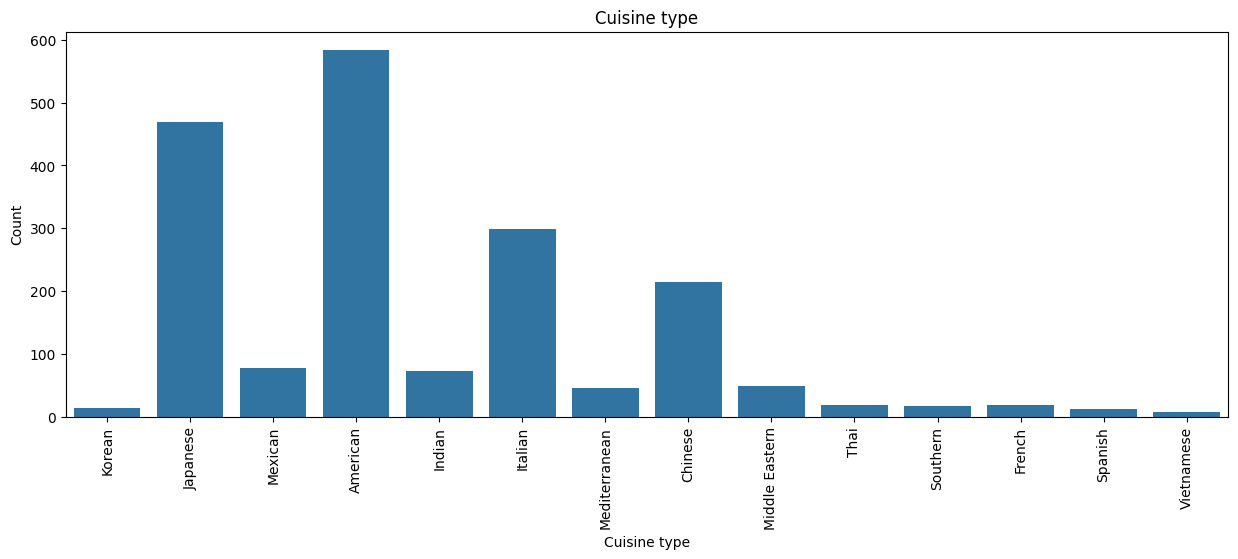

In [ ]:
# Countplot for cuisine type
plt.figure(figsize=(15,5))
sns.countplot(data=foodhub, x= 'cuisine_type');
plt.xticks(rotation=90);
plt.xlabel('Cuisine type');
plt.ylabel('Count');
plt.title('Cuisine type');
plt.show()

Observation:
Detail about the cuisine types:
There are 14 different cuisine types namely:
Korean, Japanese, Mexican, American, Indian, Italian,
       Mediterranean, Chinese, Middle Eastern, Thai, Southern,
       French, Spanish, Vietnamese.

American, Japanese, Italian and Chinese are the top ordered cuisines.
 American has the highest count of approximately 580 orders.Japanese has approximately 460, Italian has 300 and Chinese has approximately 210 orders.
 Mexican and Indian cuisine is just below 100.

**Observation on Cost of orders**





In [ ]:
# Distribution cost of the orders

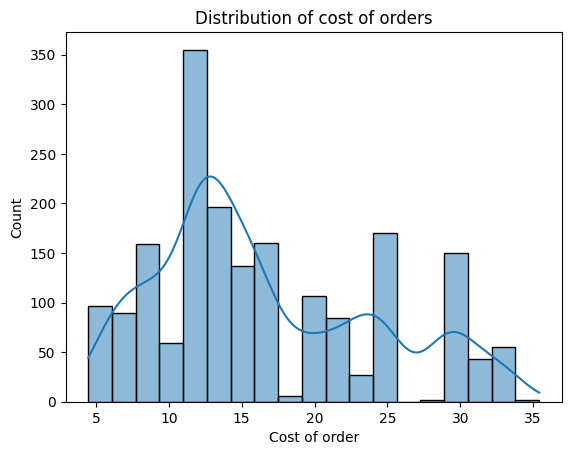

In [ ]:
#Histogram for cost of order
sns.histplot(data=foodhub,x='cost_of_the_order', kde=True);
plt.xlabel('Cost of order');
plt.ylabel('Count');
plt.title('Distribution of cost of orders');
plt.show()

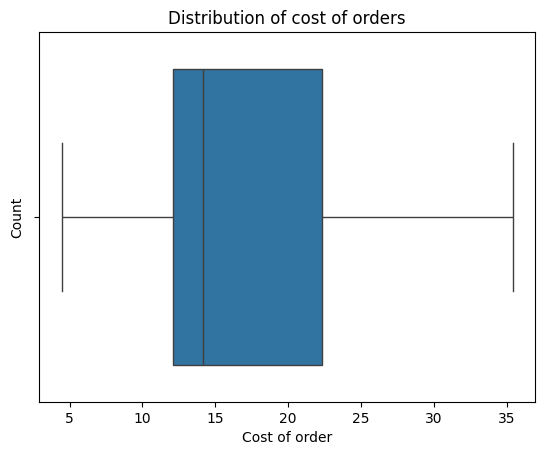

In [ ]:
#Boxplot for cost of order
sns.boxplot(data=foodhub,x='cost_of_the_order');
plt.xlabel('Cost of order');
plt.ylabel('Count');
plt.title('Distribution of cost of orders');
plt.show()

Observation:
Distribution of cost of orders:
The cost of the order ranges between a minimum of 4.5 dollar and a maximum of 35.41 dollar with an average amount of 16.5 dollar. The median price is 14 dollar.
The pattern is skewed to the right and no outliers are seen.

**Observation on Rating**

In [ ]:
# Unique values for rating
foodhub['rating'].unique()

array([nan,  5.,  3.,  4.])

In [ ]:
foodhub['rating'].median()

5.0

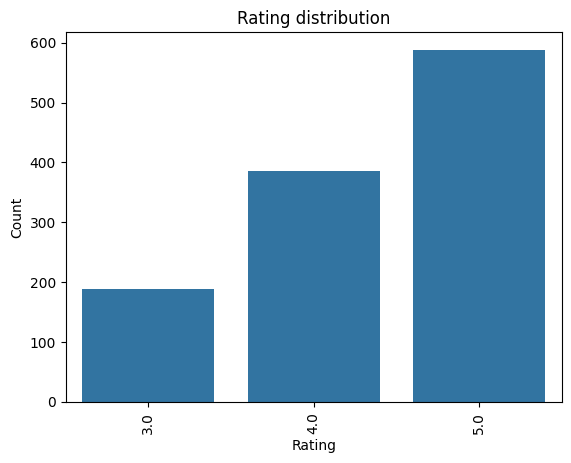

In [ ]:
# Evaluate rating distribution
sns.countplot(data=foodhub, x='rating',);
plt.xticks(rotation=90);
plt.xlabel('Rating');
plt.ylabel('Count');
plt.title('Rating distribution');
plt.show()


Observation:

The minimum rating is 3 and the maximum and median ratings are both 5.
Approximately 590 orders has been rated as 5. Approximately 390 orders has a rating of 4. About 190 has a rating of 3.

In [ ]:
#Determine rating counts
rating_counts=foodhub['rating'].value_counts()
print(rating_counts)

rating
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64


In [ ]:
#Determine percentage rating counts
Percentage_rating_counts=rating_counts/1898 *100
rounded_percentage_rating_counts=round(Percentage_rating_counts,2)
print(rounded_percentage_rating_counts)


rating
5.0    30.98
4.0    20.34
3.0     9.91
Name: count, dtype: float64


Observation:
The highest rating is 5 at 30.98%, second is rating 4 at 20.34% and last is rating 3 at 9.91%.

**Observations on Food preparation time**

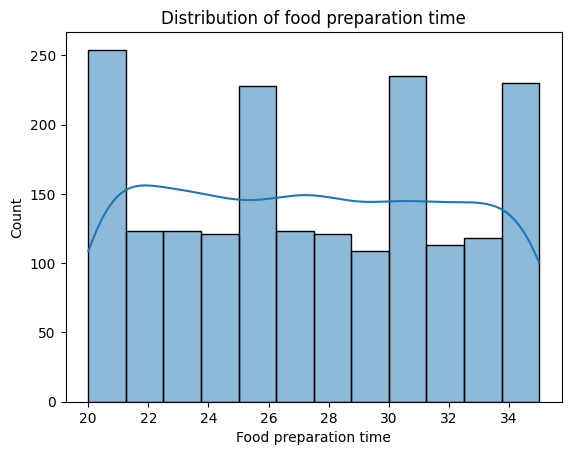

In [ ]:
# Distribution of food preparation time
# Univariate analysis
#Histogram for food preparation time
sns.histplot(data=foodhub,x='food_preparation_time', kde=True);
plt.xlabel('Food preparation time');
plt.ylabel('Count');
plt.title('Distribution of food preparation time');
plt.show()

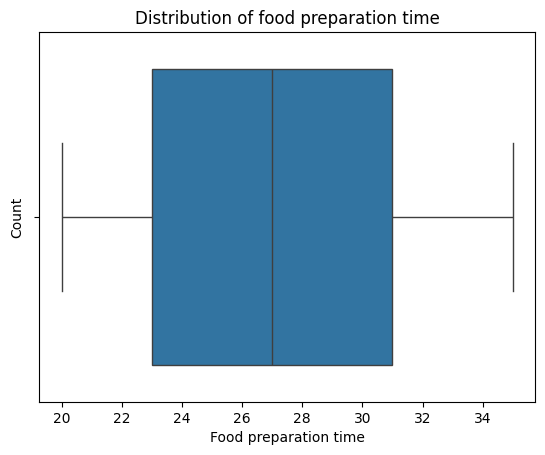

In [ ]:
#Boxplot for food preparation time
sns.boxplot(data=foodhub,x='food_preparation_time');
plt.xlabel('Food preparation time');
plt.ylabel('Count');
plt.title('Distribution of food preparation time');
plt.show()

Observation:
Distribution of food preperation time:

The food preparation time is almost evenly distributed with a minimum of 20 minutes and a maximum time of 35 minutes. The median is in the middle of Q1 and Q3. The average preparation time is is 27.37 minutes according to statistical analysis. The median is also approximately 27 minutes.

**Observation on Delivery time**

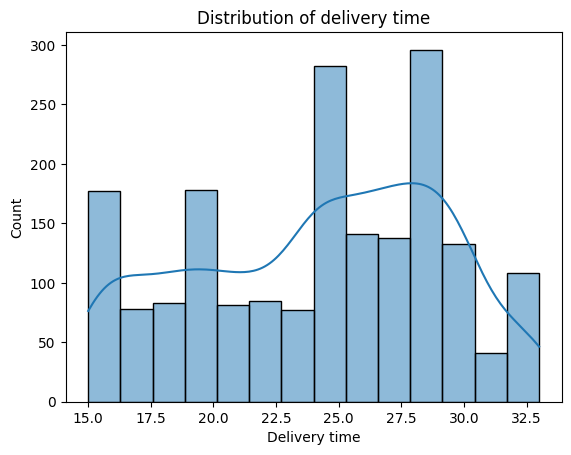

In [ ]:
#Distribution of delivery time
#Histogram for food preparation time
sns.histplot(data=foodhub,x='delivery_time', kde=True);
plt.xlabel('Delivery time');
plt.ylabel('Count');
plt.title('Distribution of delivery time');
plt.show()

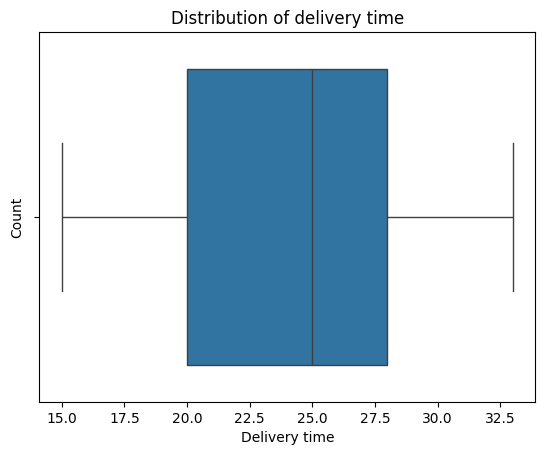

In [ ]:
#Boxplot for delivery time
sns.boxplot(data=foodhub,x='delivery_time');
plt.xlabel('Delivery time');
plt.ylabel('Count');
plt.title('Distribution of delivery time');
plt.show()

Observation:
Distribution of delivery time:

The minimum delivery time is 15 minutes and the maximum is 33 minutes. The median delivery time is 25 minutes. The distribution is skewed to the left there are no outliers seen.

**Observations on Day of the week**

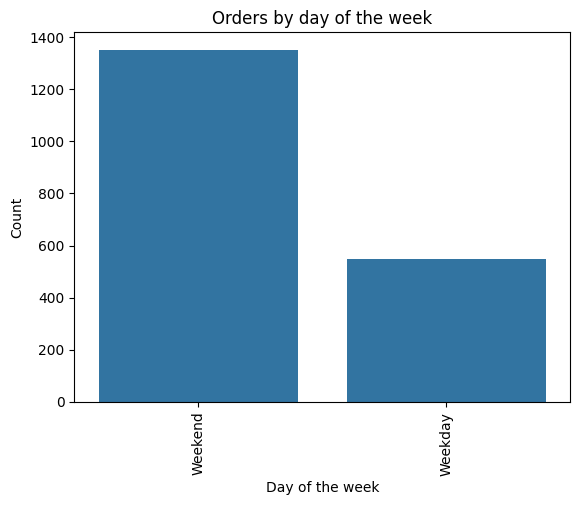

In [ ]:
# Visualise orders according to the day of the week
sns.countplot(data=foodhub, x= 'day_of_the_week');
plt.xticks(rotation=90);
plt.xlabel('Day of the week');
plt.ylabel('Count');
plt.title('Orders by day of the week');
plt.show()


In [ ]:
foodhub['day_of_the_week'].value_counts('weekday')


,proportion
day_of_the_week,
Weekend,0.711802
Weekday,0.288198


Observation:
71.18% of orders are on weekends and 28.81% of orders are on weekdays.

### **Top 5 restaurants in terms of the number of orders received**


In [ ]:
# Creating a DataFrame
df = pd.DataFrame(foodhub)

# Count number of orders per restaurant
restaurant_order_count = df['restaurant_name'].value_counts().head(5),

# Display Top 5 restaurants
print(restaurant_order_count)


(restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64,)


Observation:
The top 5 restaurants in terms of number of orders received are: 219 orders from Shake Shack,132 from The Meatball Shop,119 from Blue Ribbon Sushi, 96 from Blue Ribbon Fried Chicken and 68 orders from Parm.    

### **Most popular cuisine on weekends**

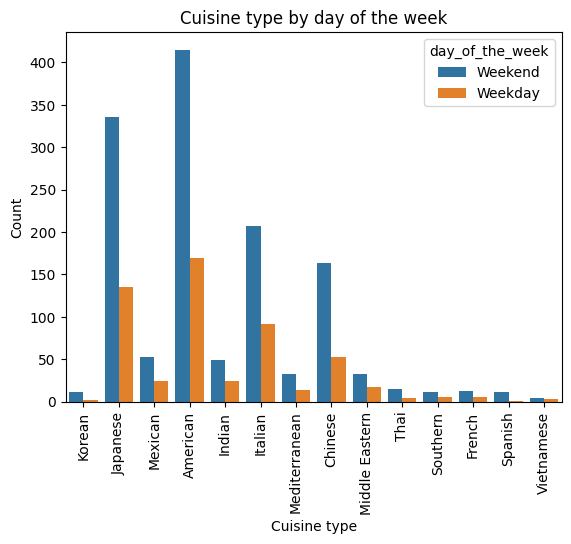

In [ ]:
# Determine most popular cuisine type over the weekend
sns.countplot(data=foodhub, x= 'cuisine_type', hue= 'day_of_the_week');
plt.xticks(rotation=90);
plt.xlabel('Cuisine type');
plt.ylabel('Count');
plt.title('Cuisine type by day of the week');
plt.show()

Observation:
The most popular cuisine type over weekends is American with count of 415, followed by Japanese with a count of 335.

In [ ]:
#Cuisine type counts over the weekend
df_weekend=foodhub[foodhub['day_of_the_week']=='Weekend']
df_weekend['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Mediterranean,32
Middle Eastern,32
Thai,15


Observation:
The most popular cuisine type over the weekend is American with about 415 orders, Second is Japenese with a count of approximately 335, third is italian with a value of 207, fourth is Chinese at about 163. Fith is Mexican, count of 53 and Indian is very close with a count of 49.

### **Percentage of orders that cost more than 20 dollars**

In [ ]:
total_amount_of_orders=foodhub[:1898]

total_amount_of_orders




,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5.0,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,NaN,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.0,23,31


In [ ]:
#Sum Cost or orders more than $20
expensive_orders= foodhub['cost_of_the_order']>20
expensive_orders


,cost_of_the_order
0,True
1,False
2,False
3,True
4,False
...,...
1893,True
1894,False
1895,True
1896,False


In [ ]:
# Calculate total expensive orders
sum_of_expensive_orders=expensive_orders.sum()
sum_of_expensive_orders

555

In [ ]:
#Percentage of orders with a cost of more than 20 dollars
total_amount_of_orders =1898
percentage_expensive_order=(sum_of_expensive_orders/total_amount_of_orders) * 100
print('Percentage of orders more than 20 dollars is:',round (percentage_expensive_order,2),'%')

Percentage of orders more than 20 dollars is: 29.24 %


Observation:
The total amount of orders that cost more than 20 dollars is 555. This is 29.24% of the total orders.



###**Determine the mean order delivery time**

In [ ]:
#Determine total delivery time: time from preperation to delivery
foodhub['total_delivery_time'] = foodhub['food_preparation_time'] + foodhub['delivery_time']
#Add total delivery column to dataframe
print ('Total_delivery_time', foodhub['total_delivery_time'])


Total_delivery_time 0       45
1       48
2       51
3       40
4       49
        ..
1893    48
1894    50
1895    55
1896    54
1897    52
Name: total_delivery_time, Length: 1898, dtype: int64


In [ ]:
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49


In [ ]:
# Total order delivery time for the column
total_delivery_time= foodhub['delivery_time'].sum()
total_delivery_time

45859

In [ ]:
# Mean order delivery time
mean_order_delivery_time= total_delivery_time/1898
rounded_percentage= round(mean_order_delivery_time,2)
print('The mean order delivery time is:',rounded_percentage,'minutes')

The mean order delivery time is: 24.16 minutes


Observation:
The mean order delivery time is 24 minutes and 16 seconds.

### **The top 3 most frequent customer ID's and the number of orders they placed**

In [ ]:
#Determine the order counts for each customer ID
from itertools import groupby
df=pd.DataFrame(foodhub)
order_counts= df.groupby(['customer_id']).size().reset_index(name='order_count')
print(order_counts)




      customer_id  order_count
0            1311            1
1            5139            1
2            5444            1
3            5693            1
4            6987            2
...           ...          ...
1195       402215            1
1196       403019            1
1197       403833            1
1198       404649            1
1199       405334            1

[1200 rows x 2 columns]


In [ ]:
#Sort the order counts in descending order to view the top 3 Customer ID's and their order numbers
sorted_foodhub=order_counts.sort_values('order_count',ascending=False,)
sorted_foodhub.head(3)


,customer_id,order_count
116,52832,13
84,47440,10
333,83287,9


Observation:
The top 3 most frequent customers are: Customer ID 52832 with	13 orders, Customer ID 47440 with 10 orders and Customer ID 83287 with 9 orders.


### **Exploratory Data Analysis: Multivariate analysis**



**Correlation by heatmap**

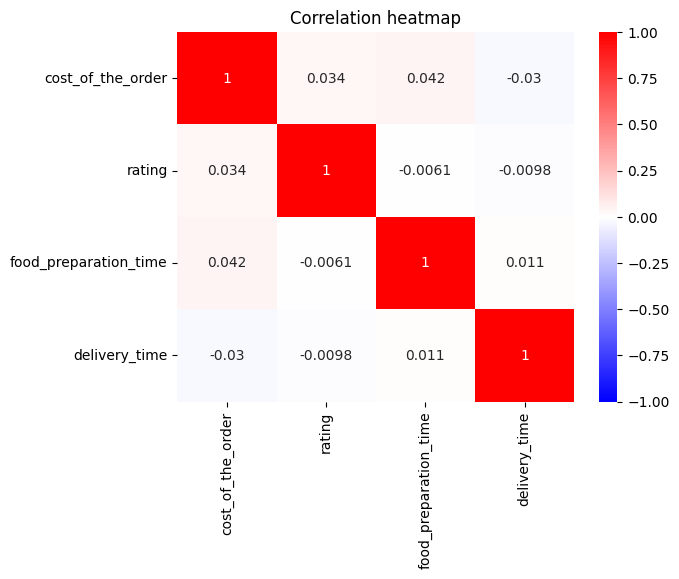

In [ ]:
#Multivariate analysis, evaluating numerical data
#Set the correlation matrix
corr_matrix=foodhub[['cost_of_the_order','rating','food_preparation_time','delivery_time', ]].corr()
# Create heatmap
sns.heatmap(data=corr_matrix, annot=True, cbar=True,cmap='bwr',vmin=-1, vmax =1)
plt.title('Correlation heatmap');
plt.show()

**Multivariate analysis by pairplot**

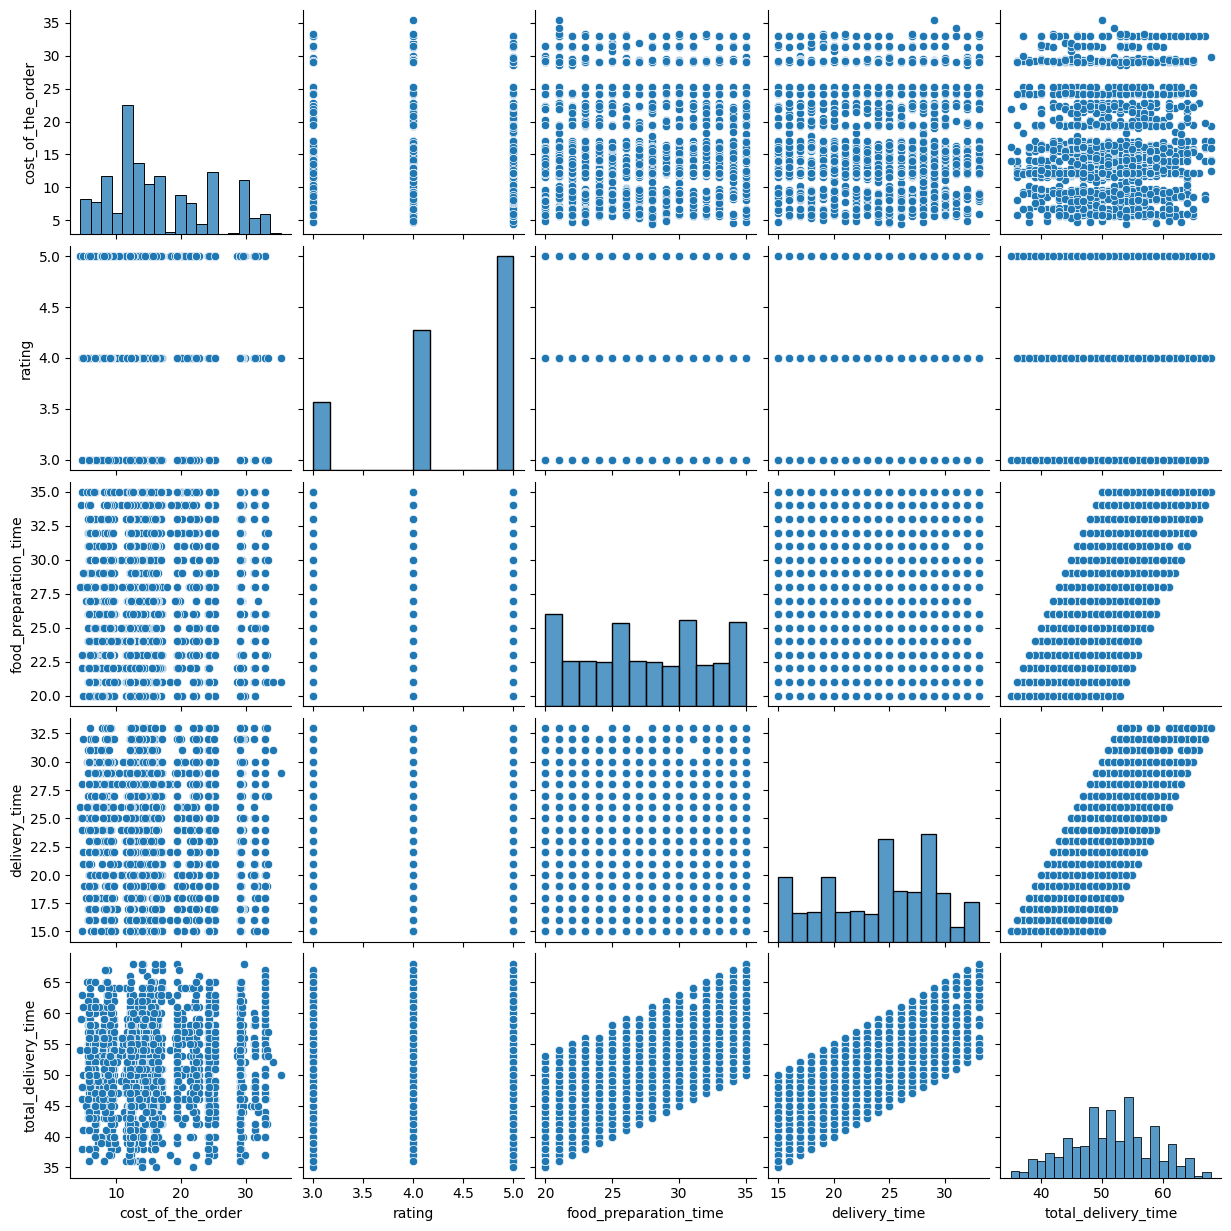

In [ ]:
sns.pairplot(data=foodhub[['cost_of_the_order','rating','food_preparation_time','delivery_time', 'total_delivery_time']]);
plt.show()

Observation:
The heatmap shows correlation between numerical values. There is a weak positive correlation between cost of order and food preparation time (0.042). There is almost no correlation between rating and food preparation time,rating and delivery time or rating and cost of order. This can also be seen in the pairplot and here a strong correlation is present between food preparation time and total delivery time, as well as delivery time an total delivery time as expected.




**Delivery time vs weekday**

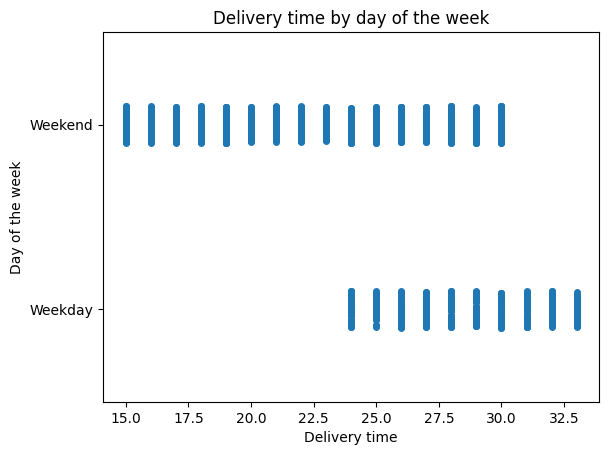

In [ ]:
sns.stripplot(data=foodhub, x= 'delivery_time',y= 'day_of_the_week');
plt.xlabel('Delivery time');
plt.ylabel('Day of the week');
plt.title('Delivery time by day of the week');
plt.show()

Observation:
The delivery time on weekdays ranges from about 24 to 33 minutes.
The delivery time on weekends ranges from about 15 to 30 minutes.

In [ ]:
# Top 5 Restaurant names relationship with number of orders
print(restaurant_order_count)

(restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64,)


**Cost of order vs cuisine**

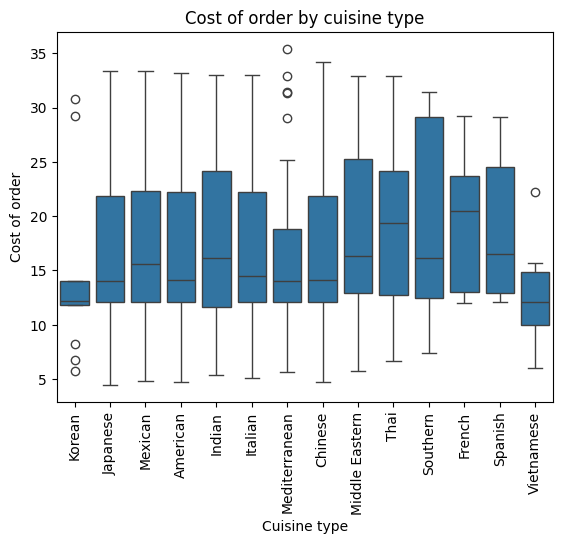

In [ ]:
#Cost of the order per cuisine type
sns.boxplot(data=foodhub, x='cuisine_type', y= 'cost_of_the_order',);
plt.xticks(rotation=90);
plt.xlabel('Cuisine type');
plt.ylabel('Cost of order');
plt.title('Cost of order by cuisine type');
plt.show();


Observation:
The minimum cost of order is around 5 dollar for the top five cuisine types, American, Japanese,Italian, Chinese and Mexican. The other cuisine types have a minimum above 5 dollars. The 75 percentile for the top selling cuisine types are at approximately 23 dollars.

**Cuisine vs Food preparation time**

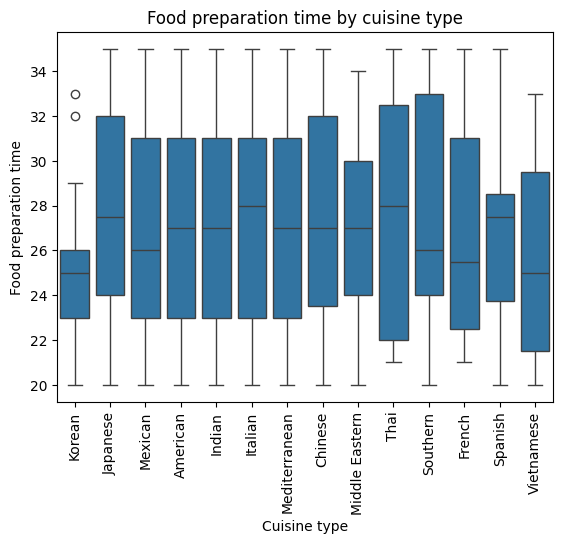

In [ ]:
#Relationship between cuisine type and food preparation time
sns.boxplot(data=foodhub, x='cuisine_type', y= 'food_preparation_time');
plt.xticks(rotation=90);
plt.xlabel('Cuisine type');
plt.ylabel('Food preparation time');
plt.title('Food preparation time by cuisine type');
plt.show();

Observation:
The median preparation times for the top 5 restuarants are around 27 minutes.

**Revenue by restaurants**

In [ ]:
# Calculate total cost of order per restaurant , display top 10
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(10)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


Observation:
The highest orders are from Shake Shack	 at 3579.53 dollars and The Meatball Shop	at 2145.21 dollars. Followed by  Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm.


**Rating vs delivery time**

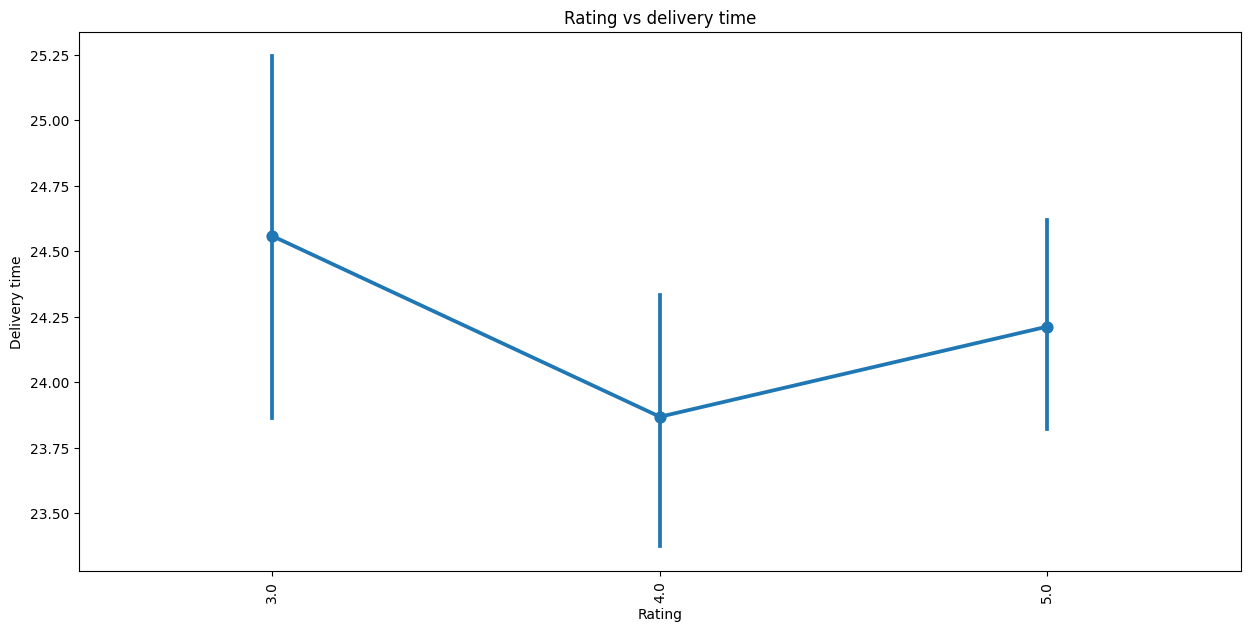

In [ ]:
#Rating vs delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(data=foodhub, x='rating', y='delivery_time',);
plt.xlabel('Rating');
plt.ylabel('Delivery time');
plt.title('Rating vs delivery time');
plt.xticks(rotation=90)
plt.show()

Observation: There is not a significant correlation between delivery time and rating. 24.5 minutes rated at 3, 23.75 minutes rated at 4 and 24.25 minutes rated at 5.

**Rating vs food preparation time**

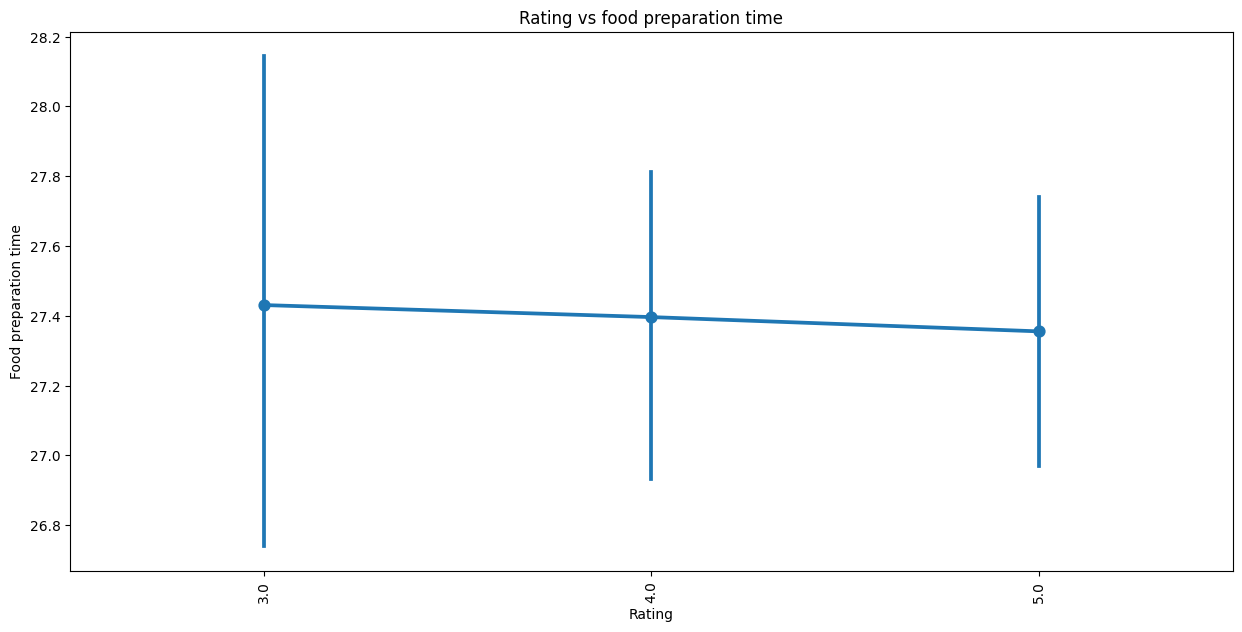

In [ ]:
# Rating vs food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(data=foodhub, x='rating', y='food_preparation_time');
plt.xlabel('Rating');
plt.ylabel('Food preparation time');
plt.title('Rating vs food preparation time');
plt.xticks(rotation=90);
plt.show()

Observation: There is not a significant correlation between food preparation time and rating. The average food preparation time is close to 27 minutes for all 3 ratings.

**Rating vs Cost of order**

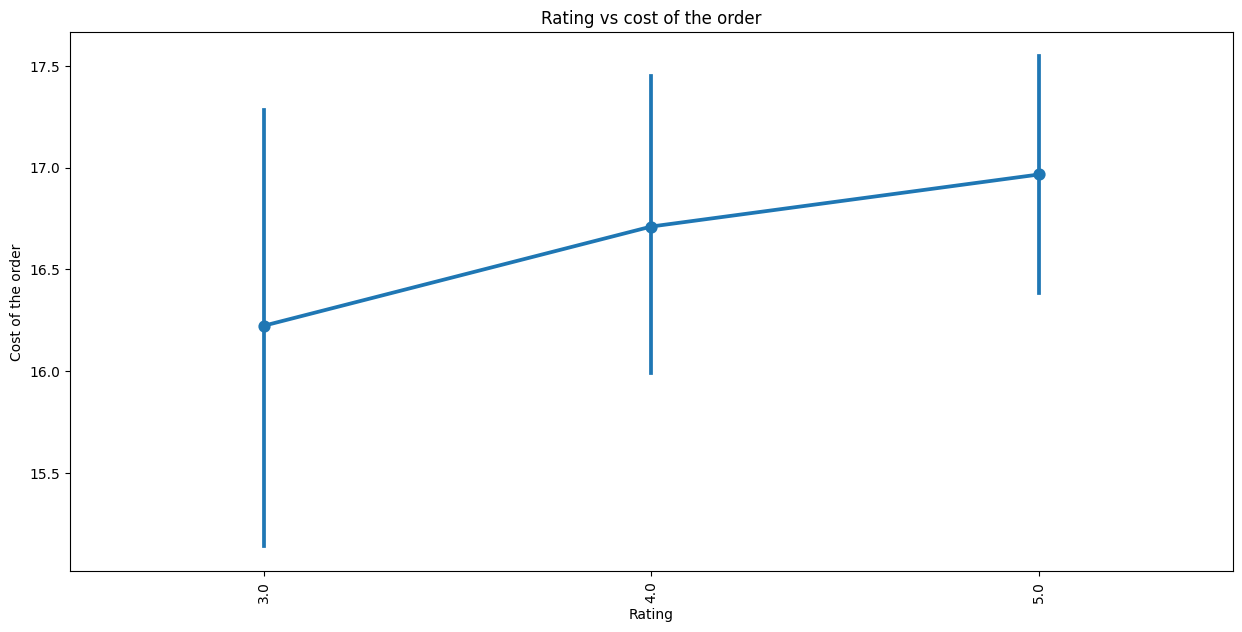

In [ ]:
# Rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(data=foodhub, x='rating', y='cost_of_the_order');
plt.xlabel('Rating');
plt.ylabel('Cost of the order');
plt.title('Rating vs cost of the order');
plt.xticks(rotation=90);
plt.show()

Higher priced orders are not rated significantly higher: the avarage cost of approximately 16.3 dollars is rated 3, the average cost of 16.6 dollars rates at 4 and the cost of 17.9 rates 5. There is not a significant correlation between order of cost and rating.

**Rating per top 5 restaurants and cuisine type**

Index(['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm'],
      dtype='object', name='restaurant_name')


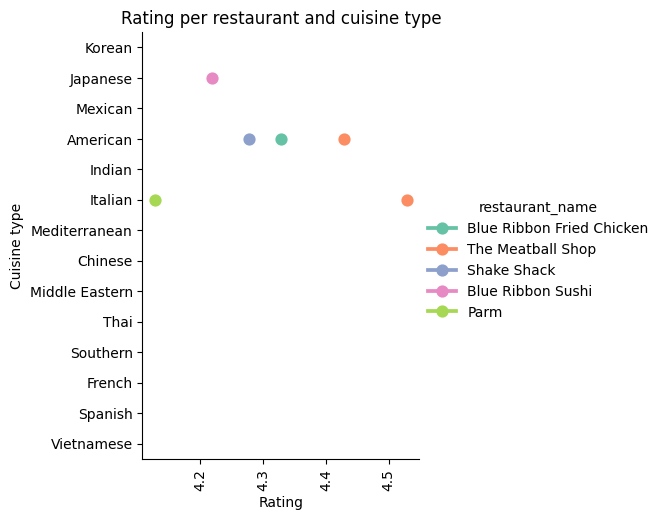

In [ ]:
# Count number of orders per restaurant
df = pd.DataFrame(foodhub)
top_5_restaurants = df['restaurant_name'].value_counts().head(5).index
print(top_5_restaurants)
top_5_df = df[df['restaurant_name'].isin(top_5_restaurants)];

# Compare rating per restaurant and cuisine type
sns.catplot(data=foodhub,x='rating', y='cuisine_type', hue= top_5_df['restaurant_name'],errorbar=None ,kind='point', palette='Set2');
plt.xticks(rotation=90);
plt.xlabel('Rating');
plt.ylabel('Cuisine type');
plt.title('Rating per restaurant and cuisine type');
plt.show()

Observation:
The Meatball Shop has top ratings for 2 cuisine types: almost 5 for Italian and 4.45 for American.

The Blue Ribbon Fried Chicken has 4.32 for American cuisine.

Shake shack has 4.25 for American cuisine.

Blue ribbon sushi has almost 4.2 for Japanese cuisine.

Parm has just above 4.1 for Italian cuisine.

American and Italian cuisine has the highest ratings.
Japanese cuisine has a lower rating. Futher investigation is needed to determine which cuisine types had missing rating data.




###**Restaurants with rating count above 50 and an average rating greater than 4**
**Eligible for a promotional offer**

In [ ]:
# Look at rating counts per restaurant
df = pd.DataFrame(foodhub)
restaurant_rating_count=df.groupby(['restaurant_name','rating']).size().reset_index(name='rating_count')
print(restaurant_rating_count)

      restaurant_name  rating  rating_count
0          'wichcraft     5.0             1
1           12 Chairs     4.0             1
2           12 Chairs     5.0             1
3     5 Napkin Burger     3.0             1
4     5 Napkin Burger     5.0             1
..                ...     ...           ...
276  ilili Restaurant     3.0             2
277  ilili Restaurant     4.0             7
278  ilili Restaurant     5.0             4
279         indikitch     4.0             1
280         indikitch     5.0             1

[281 rows x 3 columns]


In [ ]:
foodhub['rating_count'] = foodhub.groupby('restaurant_name')['rating'].transform('count')
foodhub.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_delivery_time,rating_count
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45,0
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48,18
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51,11
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40,64
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49,2


In [ ]:
top_rating_counts=foodhub[foodhub['rating_count']>50].groupby(['restaurant_name']).size()
print(top_rating_counts)


restaurant_name
Blue Ribbon Fried Chicken     96
Blue Ribbon Sushi            119
Shake Shack                  219
The Meatball Shop            132
dtype: int64


In [ ]:
ratings_by_restaurant = df.groupby(['restaurant_name'])['rating'].mean()

print(ratings_by_restaurant)

restaurant_name
'wichcraft          5.000000
12 Chairs           4.500000
5 Napkin Burger     4.000000
67 Burger           5.000000
Alidoro                  NaN
                      ...   
Zero Otto Nove      4.000000
brgr                3.000000
da Umberto          5.000000
ilili Restaurant    4.153846
indikitch           4.500000
Name: rating, Length: 178, dtype: float64


In [ ]:
df = pd.DataFrame(foodhub)
# List of restaurants you're interested in
target_restaurants = ['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi',
    'Shake Shack', 'The Meatball Shop']


# Calculate mean rating for each specified restaurant
mean_ratings = df[df['restaurant_name'].isin(target_restaurants)].groupby('restaurant_name')['rating'].mean()

# Display the mean ratings
print(mean_ratings)


restaurant_name
Blue Ribbon Fried Chicken    4.328125
Blue Ribbon Sushi            4.219178
Shake Shack                  4.278195
The Meatball Shop            4.511905
Name: rating, dtype: float64


Observations:
The following 4 restaurants have a rating count of more than 50 and a average rating greater than 4 and are eligible for the promotional offer:
Blue Ribbon Fried Chicken 4.3, Blue Ribbon Sushi 4.2, Shake Shack 4.3 and The Meatball Shop 4,5.

### **Net revenue generated across all orders**

In [ ]:
def calculate_revenue(cost_of_the_order):
    """
    Calculate revenue based on the cost of the order.

    Revenue is determined by the following conditions:
    - 25% of the cost if cost_of_the_order > $20
    - 15% of the cost if cost_of_the_order > $5
    - 0% of the cost if cost_of_the_order <= $5
    """
    if cost_of_the_order > 20:
        revenue = cost_of_the_order * 0.25
    elif cost_of_the_order > 5:
        revenue = cost_of_the_order * 0.15
    else:
        revenue = cost_of_the_order * 0

    return revenue

    # Apply the revenue calculation to the 'cost_of_the_order' column
df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)

print(df)



      order_id  customer_id                        restaurant_name  \
0      1477147       337525                                Hangawi   
1      1477685       358141              Blue Ribbon Sushi Izakaya   
2      1477070        66393                            Cafe Habana   
3      1477334       106968              Blue Ribbon Fried Chicken   
4      1478249        76942                       Dirty Bird to Go   
...        ...          ...                                    ...   
1893   1476701       292602  Chipotle Mexican Grill $1.99 Delivery   
1894   1477421       397537                              The Smile   
1895   1477819        35309                      Blue Ribbon Sushi   
1896   1477513        64151                      Jack's Wife Freda   
1897   1478056       120353                      Blue Ribbon Sushi   

       cuisine_type  cost_of_the_order day_of_the_week  rating  \
0            Korean              30.75         Weekend     NaN   
1          Japanese        

In [ ]:
# Apply the function to the 'cost_of_the_order' column and create a new 'revenue' column
foodhub['revenue'] = foodhub['cost_of_the_order'].apply(calculate_revenue)

print(foodhub)




      order_id  customer_id                        restaurant_name  \
0      1477147       337525                                Hangawi   
1      1477685       358141              Blue Ribbon Sushi Izakaya   
2      1477070        66393                            Cafe Habana   
3      1477334       106968              Blue Ribbon Fried Chicken   
4      1478249        76942                       Dirty Bird to Go   
...        ...          ...                                    ...   
1893   1476701       292602  Chipotle Mexican Grill $1.99 Delivery   
1894   1477421       397537                              The Smile   
1895   1477819        35309                      Blue Ribbon Sushi   
1896   1477513        64151                      Jack's Wife Freda   
1897   1478056       120353                      Blue Ribbon Sushi   

       cuisine_type  cost_of_the_order day_of_the_week  rating  \
0            Korean              30.75         Weekend     NaN   
1          Japanese        

In [ ]:
#Confirm Revenue column
foodhub.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_delivery_time,rating_count,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45,0,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48,18,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51,11,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40,64,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49,2,1.7385


In [ ]:
#Calculate total revenue
total_revenue = foodhub['revenue'].sum()
print('Total Revenue is ',round(total_revenue,2), 'dollars')

Total Revenue is  6166.3 dollars


Observation:
The net revenue generated by the company across all orders is 6166.30 dollars.

### **Percentage delivery time more than 60 minutes**

In [ ]:
#Identify total delivery time which was more than 60 minutes
boolean_mask = df['total_delivery_time'] > 60
boolean_mask

,total_delivery_time
0,False
1,False
2,False
3,False
4,False
...,...
1893,False
1894,False
1895,False
1896,False


In [ ]:
filtered_data = df[boolean_mask]

filtered_data



,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_delivery_time,rating_count,revenue
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,63,4,0.8955
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,NaN,34,28,62,0,0.8880
19,1477354,67487,Blue Ribbon Sushi,Japanese,16.20,Weekend,4.0,35,26,61,73,2.4300
24,1476714,363783,Cafe Mogador,Middle Eastern,15.86,Weekday,NaN,32,29,61,13,2.3790
54,1477760,130507,Jack's Wife Freda,Mediterranean,22.75,Weekend,3.0,35,29,64,19,5.6875
...,...,...,...,...,...,...,...,...,...,...,...,...
1869,1476923,50199,J. G. Melon,American,19.40,Weekday,4.0,35,26,61,12,2.9100
1873,1478148,261371,Shake Shack,American,22.31,Weekend,NaN,35,28,63,133,5.5775
1875,1478039,292343,Amy Ruth's,Southern,12.23,Weekday,NaN,32,33,65,2,1.8345
1880,1477466,222734,Shake Shack,American,13.97,Weekend,5.0,35,27,62,133,2.0955


In [ ]:
#Count of all the total delivery time values in the dataframe
Total=filtered_data['total_delivery_time'].count()
Total

200

In [ ]:
#Percentage of the total deliveries that the total delivery time more than 60 minutes
Percentage=(Total/1898)*100
print('Percentage of the total deliveries that the total delivery time more than 60 minutes is:',round(Percentage,2),'%')

Percentage of the total deliveries that the total delivery time more than 60 minutes is: 10.54 %


Observation:
10.54% of the orders take more than 60 minutes to get delivered from the time the order was placed.

### **Comparison of mean delivery time on weekdays and weekends**

In [ ]:
# Count delivery time for weekdays and weekends
grouped_data = foodhub.groupby('day_of_the_week')['delivery_time'].count()
grouped_data


,delivery_time
day_of_the_week,
Weekday,547
Weekend,1351


In [ ]:
# Calculate meand delivery times
mean_delivery_time_weekday = foodhub.groupby('day_of_the_week')['delivery_time'].mean()
mean_delivery_time_weekday


,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


### **Business insights:**




**1. Popular cuisine types which are high rated**

American, Japanese, Italian and Chinese cuisine types are the most ordered cuisines, especially over weekends and have high ratings. Mexican and Indian cuisine fare below the above list. Cuisine types that have the highest ratings are American and Italian.

**2.Insights regarding ratings**

The average rating score is 4.3 which reflects customer satisfaction. 38.7% of the rating data is missing, which is significant. Decreasing this amount and knowing more about customer satisfaction will improve data reliability and increase the potential to address certain areas to improve the business.

**3. Preparation and delivery process, operating efficiently**

Preparation time averages 27.37 minutes. Delivery time is faster over a weekend with an average of 22 minutes; during weekdays the average is 28 minutes. This may be due to less traffic or better delivery efficiency over weekends.

**4. Revenue insights**

The distribution of the cost of orders is skewed to the right with a range between 4.5 and 35.4 dollars. The average cost is 16.5 dollars, and the median order cost is 14 dollars. 29.24% of the total orders cost more than 20 dollars. This may be skewing the data to the right. The total net revenue was $6,166.30.

**5. Restaurant performance**

The following 4 restaurants have a rating count of more than 50 and an average rating greater than 4 and are eligible for the promotional offer: Blue Ribbon Fried Chicken rated 4.3, Blue Ribbon Sushi rated 4.2, Shake Shack raed 4.3 and The Meatball Shop rated 4,5. These are the top-performing restaurants.

**5.	Top Customers:**
 The most frequent customers are Customer ID 52832 (13 orders), Customer ID 47440 (10 orders), and Customer ID 83287 (9 orders).

**6. No correlation between rating and total delivery time.**
This indicates that when the customers are satisfied with the quality of the order, the time from preparation until the time of delivery does not influence their rating. 10.5% of the orders took more than 60 minutes to deliver.

### **Recommendations:**



**1. High-rated cuisine types**

a.	Popular cuisines such as American and Japanese should be used for targeted promotions, especially during weekends, which are the most popular order times.

b.	 Once capacity is reached, Foodhub could consider adding another restaurant specialising in these highly rated cuisine types.

c.	Special deals can be offered for Italian food, which is also popular.

**2. Optimising delivery efficiency**

Delivery time is faster over weekends. Consider the following options to improve weekday delivery time:

a.	 different driver routes or

b.	partner with more delivery services.

**3. Increase customer feedback**

Knowing more about customer satisfaction will improve data reliability and increase the potential to address certain areas to improve the business.
This can be achieved by implementing an easy-to-use rating on the ordering app, to be completed before closing of the transaction.

When a greater percentage of customer rating information is available, better insights and recommendations can be delivered, especially regarding underperforming restaurants and cuisine types.

**4. Focus on borderline-performing cuisine types**

a.	Mexican and Indian cuisine is close to the higher-rated cuisines but with lower order counts. Focus on these cuisines through promotions, which will enlarge the consumer base.

b.	While better ratings are achieved, ratings under three can be optimised
by improving food quality and/or delivery times.

**5. Customer reward programs can be introduced.**

a.	Reward customers who order frequently with, for instance, a free delivery for every ten orders.

b.	Customers who place orders above 20 dollars can be rewarded with loyalty points.


These recommendations can be used to encourage the increase in sales of highly rated cuisine types, which will boost revenue. Delivery efficiency can be optimised, and improved customer feedback will ensure better future insights and increased customer satisfaction. Growth in potential of lower-rated order types will contribute to an increase in revenue. Customer reward programmes will enhance marketing and ensure customer loyalty.


